# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [ ]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

Write a function `classify_number(n)` that:
- Returns `"negative"` if `n < 0`
- Returns `"zero"` if `n == 0`
- Returns `"small positive"` if `0 < n <= 10`
- Returns `"large positive"` otherwise

In [ ]:
def classify_number(n):
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    elif 0 < n <= 10:
        return "small positive"
    else:
        return "large positive"
    pass

# Tests
assert classify_number(-5) == "negative"
assert classify_number(0)  == "zero"
assert classify_number(7)  == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

Given the list `words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']`:

1. Build a **dict** `word_count` mapping each word to its frequency using only a loop (no `Counter`).
2. Using a **set**, find all unique words and store in `unique_words`.
3. Using a **list comprehension**, build `long_words` containing words with more than 5 characters.

In [ ]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

word_count = {}

for word in words:
    if word in word_count:
        word_count[word] += 1
    else:
        word_count[word] = 1

unique_words = set(words)

long_words = [word for word in words if len(word) > 5]

# Tests
assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

Write `safe_divide(a, b)` that:
- Returns `a / b` normally
- Returns `None` if `b == 0` (catch `ZeroDivisionError`)
- Raises `TypeError` with message `"Inputs must be numeric"` if either input is not a number

In [ ]:
def safe_divide(a, b):

    if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
        raise TypeError("Inputs must be numeric")

    try:
        return a / b
    except ZeroDivisionError:
        return None
    pass

# Tests
assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None
try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"
print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

1. Write a function `apply_twice(f, x)` that applies function `f` to `x` twice: `f(f(x))`.
2. Using a **lambda**, create `triple` that multiplies its input by 3.
3. Demonstrate: `apply_twice(triple, 4)` should return `36`.

In [ ]:
def apply_twice(f, x):
    return f(f(x))

triple = lambda x: x * 3

result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")

1.4 passed ✓


---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

1. Create a 1D array `arr1d` of integers 0–11.
2. Reshape it into a 2D array `arr2d` of shape `(3, 4)`.
3. Reshape `arr1d` into a 3D array `arr3d` of shape `(2, 2, 3)`.
4. Print the shape, ndim, and dtype of each.

In [ ]:
import numpy as np
arr1d = np.arange(12)
arr2d = arr1d.reshape(3, 4)
arr3d = arr1d.reshape(2, 2, 3)

for arr in [arr1d, arr2d, arr3d]:
    print(arr.shape, arr.ndim, arr.dtype)

# Tests
assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")

(12,) 1 int64
(3, 4) 2 int64
(2, 2, 3) 3 int64
2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

Using `arr2d` from above:
1. Extract the **second row** → `row2`
2. Extract the **third column** → `col3`
3. Extract the **bottom-right 2×2 submatrix** → `sub`
4. Use **boolean indexing** to get all elements greater than 7 → `gt7`

In [ ]:
row2 = arr2d[1]
col3 = arr2d[:, 2]
sub = arr2d[1:, 2:]
gt7 = arr2d[arr2d > 7]

# Tests
assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]
print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Product

Given:
```
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
```

1. Compute **element-wise product** `C = A * B`
2. Compute **matrix multiplication** `D = A @ B`
3. Compute the **dot product** of vectors `[1,2,3]` and `[4,5,6]` → `dp`
4. Multiply all elements of `A` by scalar 3 → `E`

In [ ]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

C = A * B
D = A @ B
dp = np.dot([1, 2, 3], [4, 5, 6])
E = 3 * A

# Tests
assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")

2.3 passed ✓


---
## Part 3 — Pandas

In [ ]:
# Load dataset — do not modify this cell
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

1. Extract the `salary` column as a **Series** → `salary_series`
2. Extract `name` and `department` columns as a **DataFrame** → `name_dept_df`
3. Print the type of each to confirm.

In [ ]:
salary_series = df["salary"]
name_dept_df = df[["name", "department"]]

assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

1. Use `iloc` to select rows 2–4 (inclusive), columns 0–2 → `iloc_result`
2. Use `loc` to select rows where index is 5 or 6, columns `name` and `salary` → `loc_result`

In [ ]:
iloc_result = df.iloc[2:5, 0:3]
loc_result = df.loc[[5, 6], ["name", "salary"]]

assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
display(iloc_result)
display(loc_result)

3.2 passed ✓


,employee_id,name,department
2,3,Carol,Engineering
3,4,Dave,HR
4,5,Eve,Engineering


,name,salary
5,Frank,68000.0
6,Grace,NaN


### 3.3 Filtering & Group By

1. Filter employees in **Engineering** with **salary > 90000** → `senior_eng`
2. Group by `department` and compute mean salary and mean performance → `dept_stats`
3. Sort `dept_stats` by mean salary descending.

In [ ]:
senior_eng = df[
    (df["department"] == "Engineering") &
    (df["salary"] > 90000)
]

dept_stats = (
    df.groupby("department")
      .agg({
          "salary": "mean",
          "performance": "mean"
      })
      .sort_values("salary", ascending=False)
)

print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[['name','salary']])
print("\nDept stats:")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Dept stats:


,salary,performance
department,,
Engineering,92200.000000,4.400000
Marketing,71666.666667,3.766667
HR,61000.000000,3.500000


### 3.4 Handling Missing Data

1. Identify which columns have missing values and how many → print a summary.
2. Fill missing `salary` with the **median salary** → `df_filled`
3. Fill missing `age` with the **mean age** (rounded to nearest int).
4. Drop rows where `performance` is missing.
5. Confirm no nulls remain.

In [ ]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()
salary_median = df_filled["salary"].median()
df_filled["salary"] = df_filled["salary"].fillna(salary_median)

age_mean = round(df_filled["age"].mean())
df_filled["age"] = df_filled["age"].fillna(age_mean)

df_filled = df_filled.dropna(subset=["performance"])

print("\nMissing values after:")
print(df_filled.isnull().sum())
assert df_filled.isnull().sum().sum() == 0, "Still has nulls!"
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

1. Represent a 2D point `(3, 4)` as a NumPy vector and compute its **L2 norm** (Euclidean length).
2. Create a 3×3 matrix `M` (use any non-trivial values).
3. Plot the vector as an arrow from the origin using `matplotlib` — label axes and title it *"Vector Visualization"*.

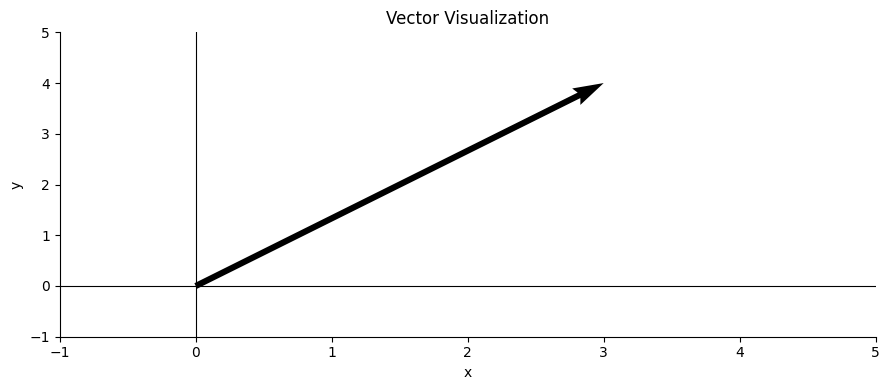

4.1 passed ✓  |v| = 5.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define vector
v = np.array([3, 4])

# Compute norm
norm_v = np.linalg.norm(v)

# Define matrix
M = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Plot
fig, ax = plt.subplots()
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1)

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8)
ax.axvline(0, color='k', lw=0.8)

plt.tight_layout()
plt.show()

# Tests
assert abs(norm_v - 5.0) < 1e-9
assert M.shape == (3, 3)

print(f"4.1 passed ✓  |v| = {norm_v}")

### 4.2 Matrix Operations in Practice

Let:
```
P = [[2, 1], [0, 3]]
Q = [[1, 4], [2, 0]]
```

1. Compute `P + Q` (matrix addition)
2. Compute `3 * P` (scalar multiplication)
3. Compute `P @ Q` (matrix multiplication)
4. Verify that matrix multiplication is **not commutative** — show `P @ Q ≠ Q @ P`.

In [ ]:
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

PplusQ = P + Q
scalar3P = 3 * P
PQ = P @ Q
QP = Q @ P

print(f"P + Q =\n{PplusQ}")
print(f"3*P =\n{scalar3P}")
print(f"P @ Q =\n{PQ}")
print(f"Q @ P =\n{QP}")
print(f"PQ == QP? {np.array_equal(PQ, QP)}")

assert not np.array_equal(PQ, QP), "They should differ!"
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]
3*P =
[[6 3]
 [0 9]]
P @ Q =
[[4 8]
 [6 0]]
Q @ P =
[[ 2 13]
 [ 4  2]]
PQ == QP? False
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

For the matrix:
```
A = [[4, 1],
     [2, 3]]
```

1. Compute eigenvalues and eigenvectors using `np.linalg.eig`.
2. **Verify** the eigenvector equation: `A @ v = λ * v` for each eigenpair.
3. Plot both eigenvectors as arrows, scaled by their eigenvalues, on a 2D plot.
4. **Explain** in a markdown cell (below): what does it geometrically mean for a matrix to stretch a vector?

Eigenvalues: None
Eigenvectors (columns):
None


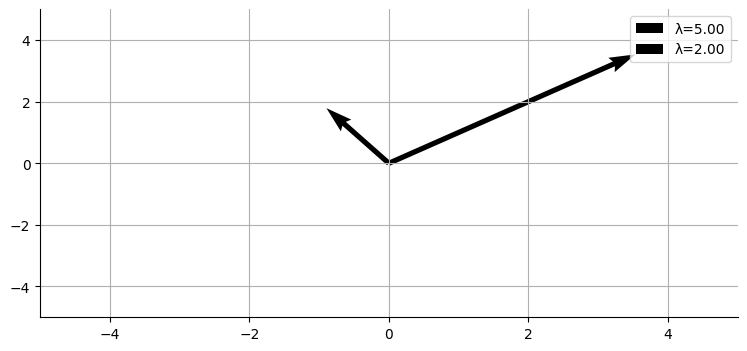

4.3 passed ✓


In [ ]:
A = np.array([[4, 1], [2, 3]], dtype=float)

eigenvalues, eigenvectors = None, None  # YOUR CODE HERE

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

# Verify Av = λv for each eigenpair
eigenvalues, eigenvectors = np.linalg.eig(A)

for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    vec = eigenvectors[:, i]

    assert np.allclose(A @ vec, lam * vec)

fig, ax = plt.subplots()

for i in range(len(eigenvalues)):
    vec = eigenvectors[:, i] * eigenvalues[i]

    ax.quiver(
        0, 0,
        vec[0], vec[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        label=f"λ={eigenvalues[i]:.2f}"
    )

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.legend()
plt.grid()
plt.show()

print("4.3 passed ✓")

**Your Geometric Explanation (4.3):**

> *Replace this text with your explanation of what eigenvalues/eigenvectors mean geometrically — what does it mean for a matrix to "stretch" or "squish" a vector?*

### 4.4 SVD & Dimensionality Reduction

1. Create a random 4×3 matrix `X` (use `np.random.seed(42)`).
2. Compute its **SVD**: `U, S, Vt = np.linalg.svd(X, full_matrices=False)`.
3. **Reconstruct** `X` from the SVD and verify it matches the original.
4. Perform a **rank-1 approximation** using only the largest singular value/vector — call it `X_approx`.
5. Explain the relationship between SVD components and PCA in the markdown cell below.

In [ ]:
np.random.seed(42)
X = np.random.randn(4, 3)

U, S, Vt = np.linalg.svd(X, full_matrices=False)

X_reconstructed = U @ np.diag(S) @ Vt
X_approx = np.outer(U[:, 0], Vt[0]) * S[0]

print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S}")
print(f"Reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}")
print(f"Rank-1 approximation:\n{X_approx}")

assert np.allclose(X, X_reconstructed, atol=1e-10), "Reconstruction failed!"
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [2.37642759 0.91384752 0.81326001]
Reconstruction error: 8.01e-16
Rank-1 approximation:
[[ 0.31621043  0.03811706 -0.07014701]
 [ 1.45405951  0.17527718 -0.32256347]
 [ 1.66945396  0.20124154 -0.37034582]
 [ 0.55465885  0.06686043 -0.12304358]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

> *Explain: what are U, S, Vt in SVD, and how do they relate to principal components? Which matrix contains the directions of maximum variance?*

---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Using the cleaned `df_filled` from Part 3:

1. Compute **descriptive statistics** for the `salary` column: mean, median, std, min, max, IQR.
2. Plot a **histogram** of salary with a KDE overlay.
3. In the markdown cell below, write one sentence each defining: *population*, *sample*, *descriptive statistic*, *inferential statistic*.

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


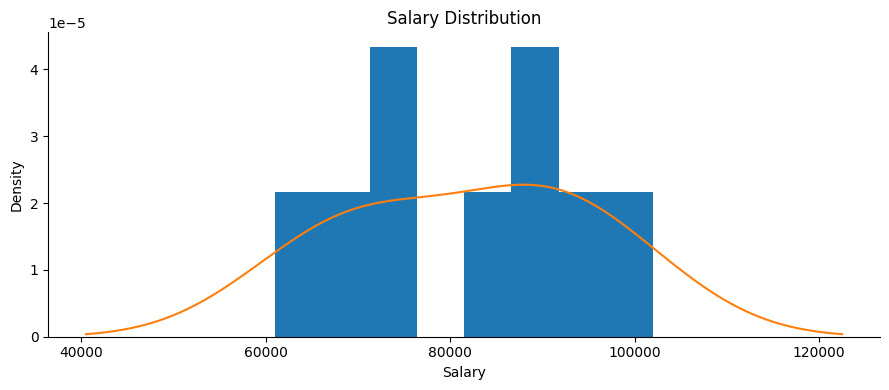

In [ ]:
salary = df_filled['salary']

mean_s = salary.mean()
median_s = salary.median()
std_s = salary.std()
min_s = salary.min()
max_s = salary.max()
q1 = np.percentile(salary, 25)
q3 = np.percentile(salary, 75)
iqr_s = q3 - q1

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

# Histogram + KDE
fig, ax = plt.subplots()
# YOUR CODE HERE
salary.plot(kind="hist", density=True, bins=8, ax=ax)
salary.plot(kind="kde", ax=ax)
ax.set_xlabel('Salary'); ax.set_title('Salary Distribution')
plt.tight_layout(); plt.show()

**Definitions (5.1):**

- **Population:** ...
- **Sample:** ...
- **Descriptive statistic:** ...
- **Inferential statistic:** ...

### 5.2 Hypothesis Testing

**Scenario:** You suspect that Engineering salaries are significantly higher than the company average.

1. State the **null hypothesis H₀** and **alternative hypothesis H₁**.
2. Run a **one-sample t-test** comparing Engineering salaries against the overall mean salary.
3. Interpret the p-value at α = 0.05.
4. Also compute the **Pearson correlation** between `salary` and `years_exp`, and interpret it.

In [ ]:
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
overall_mean = df_filled['salary'].mean()

# One-sample t-test
from scipy import stats
t_stat, p_value = stats.ttest_1samp(
    eng_salaries,
    overall_mean
)

print(f"Overall mean salary: {overall_mean:.0f}")
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Reject H0 at α=0.05? {p_value < 0.05}")

# Pearson correlation
r, r_pval = stats.pearsonr(
    df_filled["salary"],
    df_filled["years_exp"]
)
print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval:.4f}")

Overall mean salary: 81889
Engineering mean salary: 94000
t-statistic: 4.0002
p-value: 0.0280
Reject H0 at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


**H₀ / H₁ and Interpretation (5.2):**

- H₀:Engineering salaries have the same mean as the company average.
- H₁: Engineering salaries have a higher mean than the company average.

- Conclusion:If p-value < 0.05, reject H₀ and conclude Engineering salaries are significantly higher.

### 5.3 Error Metrics

Given these predictions and actuals, **implement from scratch** (no sklearn):
- MAE, MSE, RMSE
- R² Score
- Adjusted R² (assume 2 features)

In [ ]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])
n, p = len(y_true), 2

mae = np.mean(np.abs(y_true - y_pred))
mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - ss_res / ss_tot
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:        {mae:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"R²:         {r2:.4f}")
print(f"Adj. R²:    {adj_r2:.4f}")

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


### 5.4 Distribution Testing & Stationarity

1. Generate two samples: `s1` ~ Normal(0, 1), `s2` ~ Exponential(1), both n=200 (seed=0).
2. Run the **Kolmogorov-Smirnov test** (`stats.kstest`) comparing each against a standard normal CDF.
3. Generate a non-stationary time series (linear trend + noise). Run the **Augmented Dickey-Fuller test** (`adfuller` from `statsmodels`) and interpret the result.
4. Difference the series once and re-run ADF to confirm stationarity.

In [ ]:
from statsmodels.tsa.stattools import adfuller

np.random.seed(0)
s1 = np.random.normal(0, 1, 200)
s2 = np.random.exponential(1, 200)

# KS test — compare each against N(0,1)
ks_s1 = stats.kstest(s1, 'norm')
ks_s2 = stats.kstest(s2, 'norm')
print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")

# ADF test on non-stationary series
t = np.arange(200)
ts = 0.05 * t + np.random.normal(0, 1, 200)

adf_result = adfuller(ts)
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value:   {adf_result[1]:.4f}")
print(f"Stationary?    {adf_result[1] < 0.05}")

# Difference once and re-run
ts_diff = np.diff(ts)
adf_diff = adfuller(ts_diff)
print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1] < 0.05}")

KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


### 5.5 Model Monitoring Concepts

1. Implement `compute_psi(expected, actual, bins=10)` that computes the **Population Stability Index** between two distributions.
2. Simulate a scenario where a model's input distribution shifts and plot both distributions.
3. In the markdown cell, define: *concept drift*, *covariate drift*, PSI thresholds (what values indicate no/minor/major shift), and one trigger for retraining.

PSI: 1.4848
Shift severity: Major


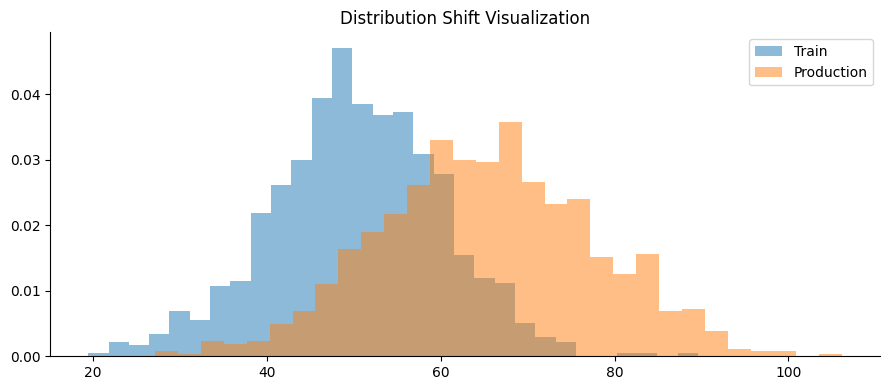

In [ ]:
def compute_psi(expected, actual, bins=10):

    epsilon = 1e-10

    breakpoints = np.percentile(
        expected,
        np.linspace(0, 100, bins + 1)
    )

    expected_counts, _ = np.histogram(
        expected,
        bins=breakpoints
    )

    actual_counts, _ = np.histogram(
        actual,
        bins=breakpoints
    )

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    psi = np.sum(
        (actual_pct - expected_pct) *
        np.log(
            (actual_pct + epsilon) /
            (expected_pct + epsilon)
        )
    )

    return psi

np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)    # training distribution
drift_dist = np.random.normal(65, 12, 1000)    # shifted production distribution

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

# Plot both distributions
fig, ax = plt.subplots()
# YOUR CODE HERE
ax.hist(train_dist, bins=30, alpha=0.5, density=True, label="Train")
ax.hist(drift_dist, bins=30, alpha=0.5, density=True, label="Production")
ax.legend(); ax.set_title('Distribution Shift Visualization')
plt.tight_layout(); plt.show()

  Concept Drift vs Covariate Drift & PSI Thresholds (5.5):  

-  Concept drift: Relationship between inputs and target changes.
-  Covariate drift: Input feature distribution changes.
-  PSI < 0.1: Stable.
-  PSI 0.1–0.2: Minor shift.
-  PSI > 0.2: Major shift.
-  Retraining trigger example: PSI consistently exceeds 0.2.


---
## Part 6 — Probability Theory

### 6.1 Core Concepts

A bag contains: 4 red, 3 blue, 3 green marbles.

1. Define the sample space and compute P(red), P(blue), P(green).
2. Two marbles drawn **without replacement**. Compute:
   - P(first=red, second=blue) — **joint probability**
   - P(second=blue | first=red) — **conditional probability**
3. Are the two draws **independent**? Show mathematically.

In [ ]:
total = 10
red, blue, green = 4, 3, 3

p_red = red / total

p_blue = blue / total

p_green = green / total

p_red_then_blue = (4/10) * (3/9)

p_blue_given_red = 3/9

independent = False

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

#P(Blue|Red)=3/9=0.333
#P(Blue)=3/10=0.30
#Since they are different, the draws are not independent.

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False


### 6.2 Distributions in the Wild

1. **Normal**: Plot N(μ=0, σ=1) and N(μ=2, σ=0.5) PDFs on the same axes.
2. **Binomial**: A coin is flipped 20 times. Plot the PMF for k=0..20 with p=0.5 and p=0.7.
3. **Poisson**: Average 3 customers/minute. Plot the PMF for k=0..15.
4. For each, write one real-world ML use case in comments.

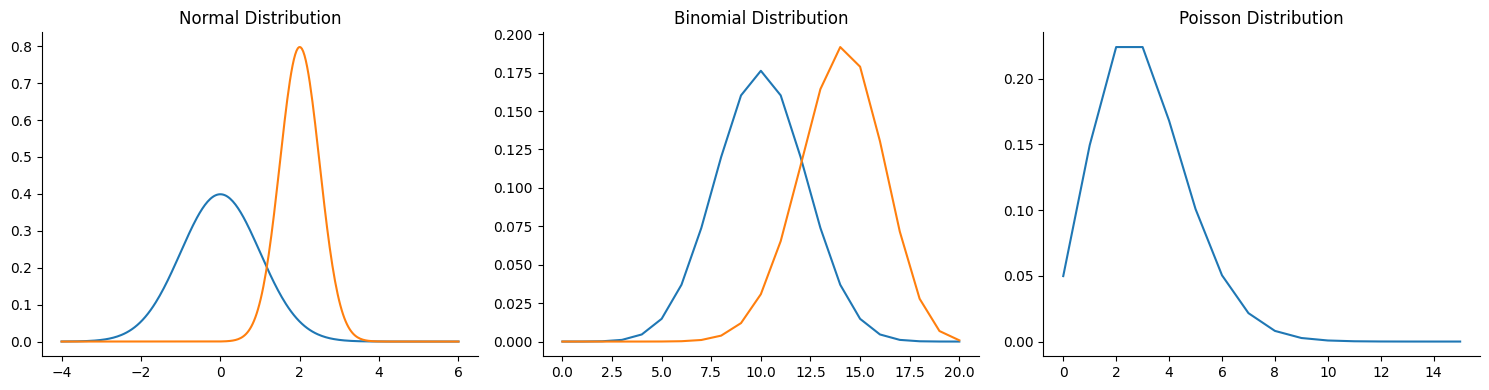

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Normal ──────────────────────────────────────────────────────────────────
x = np.linspace(-4, 6, 300)
from scipy import stats
axes[0].plot(x, stats.norm.pdf(x, 0, 1))
axes[0].plot(x, stats.norm.pdf(x, 2, 0.5))
# ML use case: measurement noise.
axes[0].set_title('Normal Distribution')

# ── Binomial ────────────────────────────────────────────────────────────────
k = np.arange(0, 21)
axes[1].plot(k, stats.binom.pmf(k, 20, 0.5))
axes[1].plot(k, stats.binom.pmf(k, 20, 0.7))
# ML use case: classification success counts.
axes[1].set_title('Binomial Distribution')

# ── Poisson ─────────────────────────────────────────────────────────────────
k2 = np.arange(0, 16)
axes[2].plot(k2, stats.poisson.pmf(k2, 3))
# ML use case: event arrivals per unit time.
axes[2].set_title('Poisson Distribution')

plt.tight_layout(); plt.show()

### 6.3 Bayes' Theorem

**Scenario — Spam filter:**
- P(Spam) = 0.30 (prior)
- P("free" | Spam) = 0.80 (likelihood)
- P("free" | Not Spam) = 0.05

1. Compute P(Spam | "free") using Bayes' theorem.
2. Implement a simple `naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham)` that returns the posterior P(Spam | word).
3. In the markdown cell, map each term — **prior, likelihood, evidence, posterior** — to the spam example.

In [ ]:
p_spam            = 0.30
p_free_given_spam = 0.80
p_free_given_ham  = 0.05
p_ham             = 1 - p_spam

# P(free) — law of total probability
p_free = (
    p_free_given_spam * p_spam
    +
    p_free_given_ham * p_ham
)

# Bayes theorem
p_spam_given_free = (
    p_free_given_spam * p_spam
) / p_free

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(
    prior_spam,
    p_word_given_spam,
    p_word_given_ham
):
    prior_ham = 1 - prior_spam

    evidence = (
        p_word_given_spam * prior_spam
        +
        p_word_given_ham * prior_ham
    )

    posterior = (
        p_word_given_spam * prior_spam
    ) / evidence

    return posterior

pred = naive_bayes_predict(0.30, 0.80, 0.05)

assert abs(pred - p_spam_given_free) < 1e-9

print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|-----------------|
| Prior | P(Spam) | 0.30 |
| Likelihood | P(word \| Spam) | P("free"|Spam)=0.80 |
| Evidence | P(word) | P("free") |
| Posterior | P(Spam \| word) | P(Spam|"free") |

### 6.4 Central Limit Theorem

1. Define a population following an **exponential distribution** (λ=1, size=100,000).
2. Repeatedly draw samples of size `n=30` and record their means — do this 5,000 times.
3. Plot the histogram of sample means.
4. Overlay the **theoretical normal distribution** predicted by the CLT: μ = population mean, σ = population_std / sqrt(n).
5. Run a KS test to confirm the distribution of sample means is approximately normal.

Population mean: 1.0005, Population std: 1.0006
Sample means mean: 0.9971, std: 0.1828
CLT predicted std: 0.1827


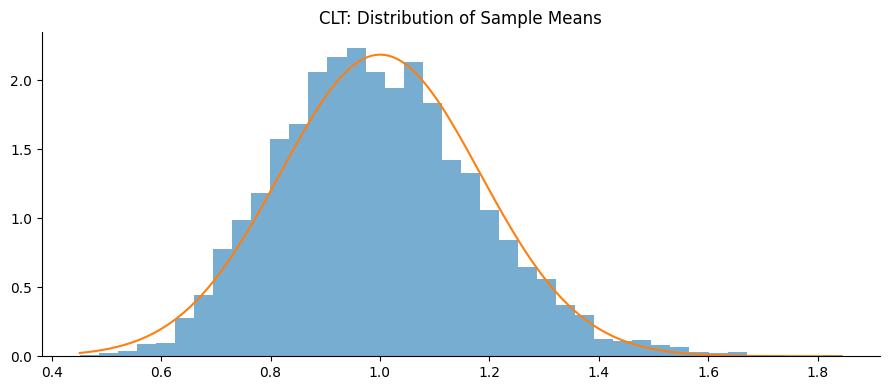

KS test p-value: 0.0000 → Approximately normal? False


In [ ]:
np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)

n_samples = 5000
sample_size = 30
sample_means = np.array([
    np.mean(
        np.random.choice(
            population,
            sample_size
        )
    )
    for _ in range(n_samples)
])

pop_mean = population.mean()
pop_std  = population.std()
clt_std = pop_std / np.sqrt(sample_size)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

# Plot
fig, ax = plt.subplots()
ax.hist(
    sample_means,
    bins=40,
    density=True,
    alpha=0.6
)

x = np.linspace(
    sample_means.min(),
    sample_means.max(),
    300
)

ax.plot(
    x,
    stats.norm.pdf(
        x,
        pop_mean,
        clt_std
    )
)
ax.set_title('CLT: Distribution of Sample Means')
plt.tight_layout(); plt.show()

# KS test
ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

**CLT Reflection (6.4):**

> The Central Limit Theorem shows that the distribution of sample means approaches a normal distribution even when the original population is not normal. This is important because many statistical methods and hypothesis tests assume normality of sampling distributions, which the CLT helps justify for sufficiently large samples.

---
## 🏁 Submission Checklist

Before submitting, verify:

- [ ] All `assert` blocks pass without errors
- [ ] All `# YOUR CODE HERE` cells are filled
- [ ] All markdown reflection cells are filled in your own words
- [ ] All plots render with labels and titles
- [ ] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`